# Plot feature selection results

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
results = dict()
results['disability'] = \
    pd.read_csv('./output/feature_selection_disability_results.csv', index_col=0)
results['disability_no_treatment'] = \
    pd.read_csv('./output/feature_selection_disability_no_treatment_results.csv', index_col=0)
results['los'] = \
    pd.read_csv('./output/feature_selection_los_results.csv', index_col=0)
results['los_no_treatment'] = \
    pd.read_csv('./output/feature_selection_los_no_treatment_results.csv', index_col=0)
results['thrombolysis'] = \
    pd.read_csv('./output/feature_selection_thrombolysis_results.csv', index_col=0)
results['thrombectomy'] = \
    pd.read_csv('./output/feature_selection_thrombectomy_results.csv', index_col=0)
    

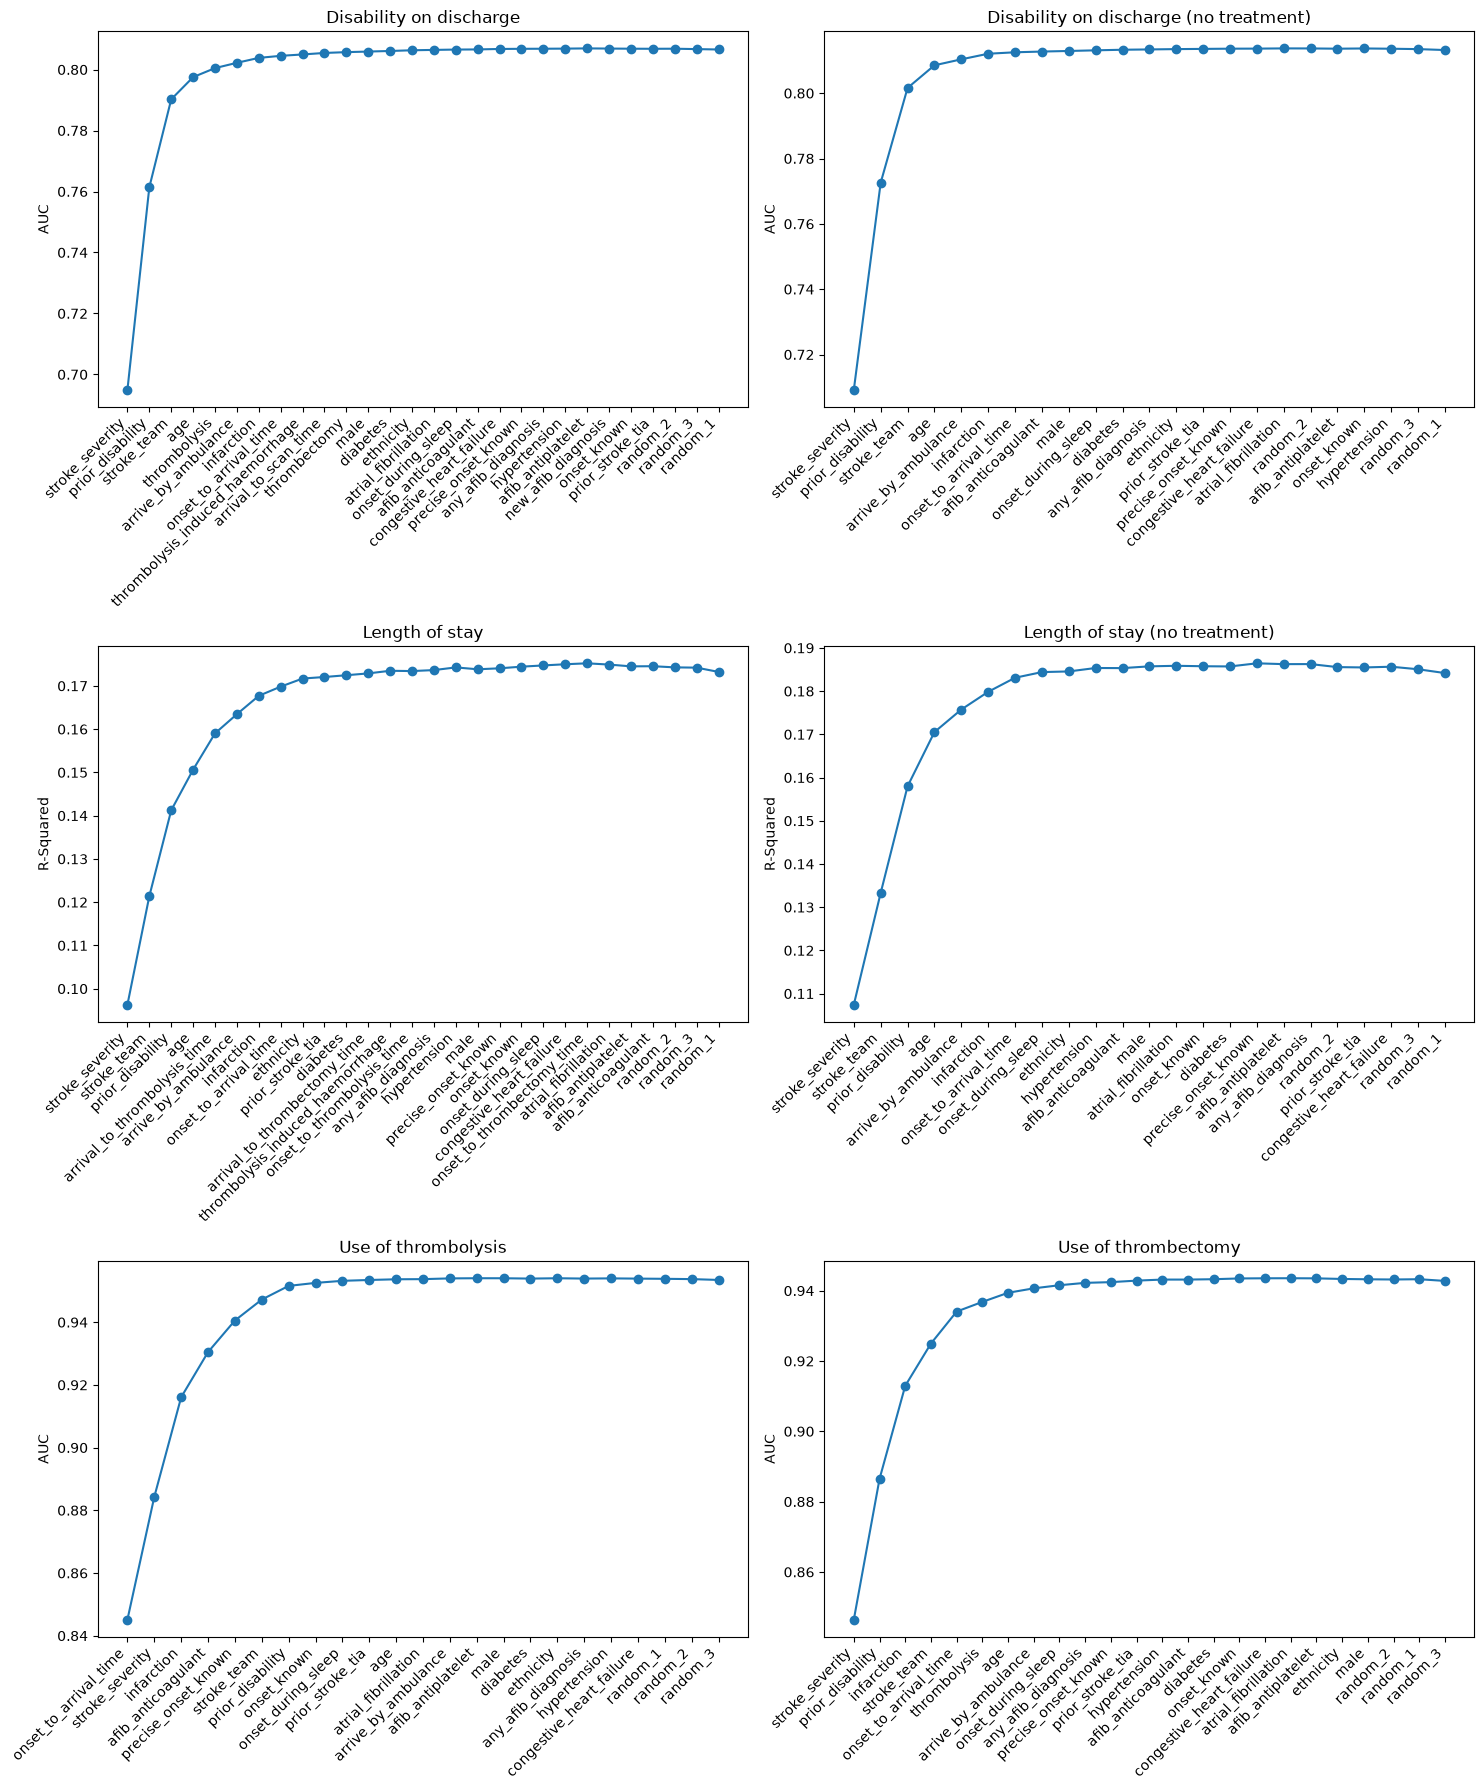

In [3]:
titles = {
    'disability': 'Disability on discharge',
    'disability_no_treatment': 'Disability on discharge (no treatment)',
    'los': 'Length of stay',
    'los_no_treatment': 'Length of stay (no treatment)',
    'thrombolysis': 'Use of thrombolysis',
    'thrombectomy': 'Use of thrombectomy'
}

# Create a 3 x 2 grid of subplots
fig, axs = plt.subplots(3, 2, figsize=(15, 18))
# Loop through each result. Plot feature as X and score as Y. Use the title of the plot as the key of the result.
for i, (key, result) in enumerate(results.items()):
    # Try score as "Mean AUC", otherwise use "Mean r2"
    if 'Mean AUC' in result.columns:
        score_col = 'Mean AUC'
    else:
        score_col = 'Mean r2'
    ax = axs[i // 2, i % 2]
    ax.plot(result['Chosen Feature'], result[score_col], marker='o')
    ax.set_title(titles.get(key, key))
    #ax.set_xlabel('Feature')
    # Use "AUC" or "R-Squared" as the Y label depending on the score column
    if score_col == 'Mean AUC':
        ax.set_ylabel('AUC')
    else:
        ax.set_ylabel('R-Squared')
    ax.set_xticks(range(len(result['Chosen Feature'])))
    ax.set_xticklabels(result['Chosen Feature'], rotation=45, ha='right')

plt.tight_layout()
plt.savefig('./output/feature_selection_results.png', dpi=300)
plt.show()